<a href="https://colab.research.google.com/github/dcarolinaj/Analysis_Urban_Mobility/blob/main/Analysis_Urban_Mobility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Urban mobility and economic productivity in LATAM cities**

## Understanding how urban mobility (levels of congestion, travel times, delays) is related to economic productivity (GDP per capita, unemployment) in major Latin American cities. Additionally, identifying in which cities to invest in transport infrastructure to increase productivity and the population’s well-being.


## **Business questions:**

1. 🤔 Which cities in Latin America show high congestion and low economic productivity?
2. 🔍 Which ones show the best combined indicators (efficient mobility and strong economy)?
3. 🧐 Which variables seem to have a stronger relationship with urban development?

### **Tools**

🐍 Python, Pandas, Numpy, Seaborn and Matplotlib.pyplot, Data Cleaning, Data Transformation.

# **Methodology**

1️⃣ The main and most careful process is data cleaning, where it is necessary to validate if there are missing values, duplicate values, validate column names such as uppercase, lowercase, spaces or special characters in the titles. Additionally, identify the data type of each column.

2️⃣ By performing the join using 'INNER', it allows a more homogeneous and complete analysis, by effectively joining the two tables with combined information to compare and obtain reliable conclusions.

3️⃣ The visualizations used were a boxplot to analyze the behavior of time according to traffic congestion. A histogram to examine the distribution of the economy 'GDP' over the number of cities, and a bar chart was also created to analyze the relationship between traffic delays compared to GDP per capita by city. Generally, most cities have a similar trend; however, it was observed that there are some cities or high values called 'outliers' that have a more representative behavior compared to other cities.

# **Data coverage**

The analysis was carried out for 55 countries, 384 cities and for the year 2024.

##**Step 1: Load and Explore**

**🎯 Objective:** Import the necessary libraries, load the CSV files into DataFrames, and perform a preliminary review to understand their contents.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
eco = pd.read_csv("/content/oecd_city_economy.csv")

In [ ]:
traffic = pd.read_csv ("/content/tomtom_traffic.csv")

In [ ]:
(traffic.head(10))

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016
5,ARE,abu-dhabi,2025-01-12 23:01:30.000,5.6,2.0,0.4,2.0,1.0,2025-01-05 23:01:30.001,8.309699,8.515687,-0.205988
6,ARE,abu-dhabi,2025-01-12 22:31:30.000,5.0,2.0,0.9,1.0,1.0,2025-01-05 22:01:30.001,8.337259,8.536889,-0.199630
7,ARE,abu-dhabi,2025-01-12 21:01:30.001,10.2,3.0,1.5,5.0,3.0,2025-01-05 21:01:00.000,8.430088,8.590590,-0.160502
8,ARE,abu-dhabi,2025-01-12 20:01:30.000,40.9,13.0,9.9,16.0,5.0,2025-01-05 20:01:00.000,9.126345,8.656094,0.470252
9,ARE,abu-dhabi,2025-01-12 19:16:30.000,197.9,17.0,20.0,37.0,7.0,2025-01-05 19:01:00.000,9.716549,9.014157,0.702391


In [ ]:
(eco.head(5))

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


## **Step 2: Explore, Clean, and Prepare the Data**

**2.1 Examine the structure of eco and traffic:**

**🎯 Objective:** Identify columns with incorrect types, distribution, and nulls; note the columns that require conversion.

In [ ]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [ ]:
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


**2.2 Rename Columns**

**🎯 Objective:** Standardize column names to avoid errors and facilitate merging the datasets.

In [ ]:
traffic = traffic.rename(columns = {'Country': 'country', 'UpdateTimeUTC': 'update_time_utc', 'City': 'city', 'JamsDelay': 'jams_delay', 'TrafficIndexLive': 'traffic_index_live', 'JamsLengthInKms': 'jams_length_in_kms', 'JamsCount': 'jams_count', 'TrafficIndexWeekAgo': 'traffic_index_week_ago', 'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago', 'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins', 'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per_10kms_mins', 'MinsDelay': 'mins_delay'})
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
eco = eco.rename(columns= {'Country': 'country', 'Year': 'year', 'City': 'city', 'City GDP/capita': 'city_gdp_capita', 'Unemployment %': 'unemployment_pct', 'PM2.5 (μg/m³)': 'pm2.5', 'Population': 'population'})
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm2.5', 'Population (M)'],
      dtype='object')

**2.3 Correct Numeric and Date Formats**

🎯 **Objective:** Ensure that date and numeric columns are in the correct formats to allow accurate analysis, calculations, and comparisons.

In [ ]:
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [ ]:
print(traffic.columns.tolist())

['country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live', 'jams_length_in_kms', 'jams_count', 'traffic_index_week_ago', 'update_time_utc_week_ago', 'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins', 'mins_delay']


- Clean Separators and Convert Numeric Columns in eco
- Calculate the total population in absolute units (Multiply by 1,000,000)

In [ ]:
eco['Population (M)'] = (eco['Population (M)'].astype(str).str.replace(',', '.',regex=False))
eco['Population (M)'] = pd.to_numeric(eco['Population (M)'], errors='coerce') * 1000000
eco.info()
eco.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     object 
 4   unemployment_pct  30 non-null     object 
 5   pm2.5             30 non-null     object 
 6   Population (M)    30 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 1.8+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5,Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2",1.530000e+19
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50",2.250000e+19
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10",1.360000e+19
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50",4.700000e+18
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00",3.900000e+18


In [ ]:
print(eco.dtypes)

year                  int64
city                 object
country              object
city_gdp_capita      object
unemployment_pct     object
pm2.5                object
Population (M)      float64
dtype: object


## **Step 3: Extract Year and Filter**

**3.1  Extract Year Column and Filter 2024**

🎯 **Objective:** Identify the year of each record and keep only the records from 2024.

In [ ]:
traffic['year'] = traffic['update_time_utc'].dt.year
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year']==2024].copy()

display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5,Population (M)
15,2024,buenos-aires,Argentina,"18.117,00",7.2%,"14,50",1.540000e+19
16,2024,sao-paulo,Brazil,"14.703,00",8.5%,"28,00",2.260000e+19
17,2024,rio-de-janeiro,Brazil,"13.349,00",9.2%,"18,40",1.370000e+19
18,2024,brasilia,Brazil,"16.251,00",7.8%,"12,80",4.800000e+18
19,2024,salvador,Brazil,"8.899,00",12.4%,"15,20",3.900000e+18


## **Step 4: Analyze and Summarize Mobility Data**

**4.1 Calculate traffic averages by city, country, and year.**

Compute the average only for the most relevant traffic metrics such as: jams_delay, traffic_index_live, jams_length_kms, jams_count, mins_delay, travel_time_live_per_10kms_mins, and travel_time_hist_per_10kms_mins.

🎯 **Objective:** Obtain a consolidated view of average traffic by city and year to analyze general patterns without relying on daily data.

In [ ]:
traffic_city_year_2024 = (traffic_2024.groupby(['city', 'country', 'year'], as_index = False)
.agg({
    'jams_delay': 'mean',
    'traffic_index_live': 'mean',
    'jams_length_in_kms': 'mean',
    'jams_count' :'mean',
    'mins_delay': 'mean',
    'travel_time_live_per_10kms_mins': 'mean',
    'travel_time_historic_per_10kms_mins': 'mean' }))

traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


* **Cities with the highest average traffic time**:




In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


## **Step 5: Merge Mobility and Economic Data**

**5.1  Merge traffic (main table) with economic indicators**

**🎯 Objective:** Combine traffic and economic information into a single DataFrame to analyze how economic conditions relate to urban mobility.

In [ ]:
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms', 'jams_count','mins_delay',
             'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm2.5','Population (M)']


traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

merged = pd.merge(traffic_2024_small, eco_2024_small, on = ['city', 'year'], how = 'inner')

merged.head(5)


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,pm2.5,Population (M)
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,"11.124,00",9.5%,"16,80",6.100000e+18
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,"11.442,00",10%,"17,60",1.130000e+19
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,"16.251,00",7.8%,"12,80",4.800000e+18
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,"18.117,00",7.2%,"14,50",1.540000e+19
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,"12.381,00",8.2%,"13,50",3.700000e+18


## **Step 6: Visualization and Relationship Analysis**

**6.1  Visualize relationships between economic and traffic data**

🎯 **Objective:** Visually analyze the distribution and relationship between traffic and economic indicators in 2024 to identify potential patterns or general trends between both variables.

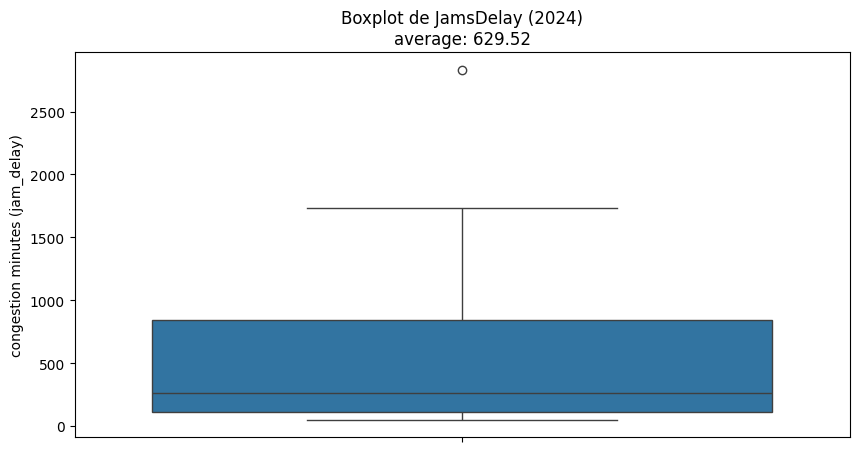

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,5))
sns.boxplot(y = merged['jams_delay'])

mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\naverage: {mean_value:.2f}')
plt.ylabel('congestion minutes (jam_delay)')
plt.show()

In [ ]:
merged['city_gdp_capita'] = (merged['city_gdp_capita'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False))

merged['city_gdp_capita'] = pd.to_numeric(merged['city_gdp_capita'], errors='coerce')

/tmp/ipykernel_27760/3653663468.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged['city_gdp_capita'])


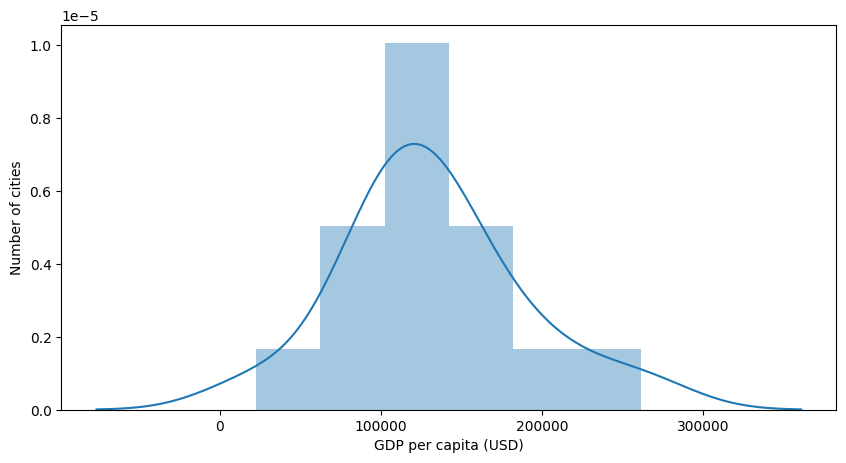

In [ ]:
plt.figure(figsize = (10, 5))
sns.distplot(merged['city_gdp_capita'])
plt.xlabel('GDP per capita (USD)')
plt.ylabel('Number of cities')
plt.show()

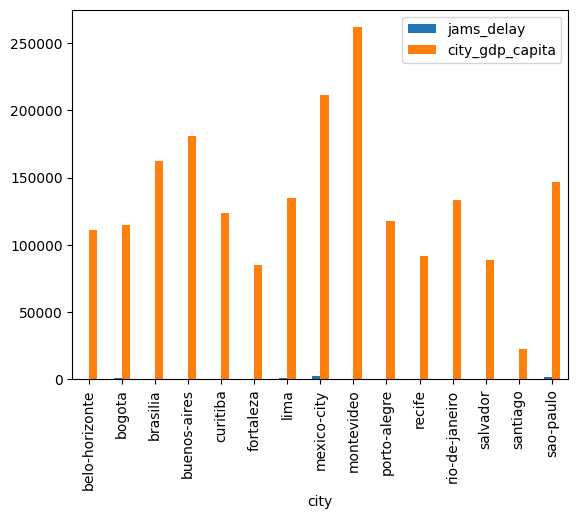

((array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
  [Text(0, 0, 'belo-horizonte'),
   Text(1, 0, 'bogota'),
   Text(2, 0, 'brasilia'),
   Text(3, 0, 'buenos-aires'),
   Text(4, 0, 'curitiba'),
   Text(5, 0, 'fortaleza'),
   Text(6, 0, 'lima'),
   Text(7, 0, 'mexico-city'),
   Text(8, 0, 'montevideo'),
   Text(9, 0, 'porto-alegre'),
   Text(10, 0, 'recife'),
   Text(11, 0, 'rio-de-janeiro'),
   Text(12, 0, 'salvador'),
   Text(13, 0, 'santiago'),
   Text(14, 0, 'sao-paulo')]),
 None)

In [ ]:
merged.plot(x = 'city', y = ['jams_delay', 'city_gdp_capita'], kind = 'bar')

plt.xticks(rotation=90), plt.show()

**6.2 Descriptive Statistics of the Dataset**

In [ ]:
traffic.describe()

,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
count,1004464,1.004464e+06,1.004464e+06,1.004464e+06,1.004464e+06,1.004464e+06,1004464,1.004464e+06,1.004464e+06,1.004464e+06,1.004464e+06
mean,2024-11-22 05:26:50.613604864,1.693280e+02,1.863959e+01,3.045143e+01,4.219045e+01,1.899557e+01,2024-11-15 05:27:48.341578496,1.373291e+01,1.311856e+01,6.143477e-01,2.024117e+03
min,2024-10-01 07:00:59.231000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2024-09-24 06:31:00,5.738284e+00,5.868690e+00,-1.340231e+01,2.024000e+03
25%,2024-10-27 10:31:30.000999936,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,2024-10-20 10:31:12.656999936,1.090516e+01,1.070496e+01,7.718445e-03,2.024000e+03
50%,2024-11-22 01:31:30,1.380000e+01,1.300000e+01,2.000000e+00,5.000000e+00,1.300000e+01,2024-11-15 01:31:00,1.303857e+01,1.260163e+01,3.200072e-01,2.024000e+03
75%,2024-12-18 01:05:07.500749824,9.020000e+01,2.800000e+01,1.580000e+01,2.600000e+01,2.900000e+01,2024-12-11 01:05:07.500749824,1.569906e+01,1.487012e+01,9.086996e-01,2.024000e+03
max,2025-01-13 04:31:30.001000,2.115770e+04,4.050000e+02,2.863800e+03,3.523000e+03,4.050000e+02,2025-01-06 05:01:30,6.794086e+01,3.676020e+01,5.064674e+01,2.025000e+03
std,NaN,5.606297e+02,2.005162e+01,9.634375e+01,1.278290e+02,2.030906e+01,NaN,4.134669e+00,3.537736e+00,1.180828e+00,3.216134e-01


# **Executive summary**

## **Context & objective:**

- Once the analysis related to congestion, travel time and GDP per capita is completed, it is evident that there is a direct relationship between congestion and travel time. The higher the congestion, the travel minutes increase linearly. However, there is no direct relationship between urban mobility and economic productivity. For example, in some countries there is a high GDP indicator and at the same time congestion is high. At the same time, in other countries, there is a high GDP but congestion is low.
- The key fundamental variables to carry out this analysis are country, city, congestion time and GDP. However, all variables are essential depending on the analysis and results to be studied.

## **Initial findings:**

According to the bar chart, when comparing traffic indices with GDP per capita, it can be observed that cities such as Montevideo and Mexico City have a high GDP per capita. In contrast, cities like Santiago and Fortaleza have a low GDP per capita. It is important to highlight that there is no direct relationship between GDP per capita and traffic indices. This may be due to different factors such as population, infrastructure, climate seasonality, transportation systems, among others.

## **Recommendations**

Bogotá could be an attractive city for investment in transport infrastructure since its level of traffic congestion is on average related to GDP per capita. Similarly, Sao Paulo presents a high congestion index compared to other countries and its GDP per capita.